# Imports

In [1]:
import pandas as pd
#%pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score


# Data import and Exploration

In [2]:
#import dataset from UCI ML Repo
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
  
# metadata 
print(diabetes_130_us_hospitals_for_years_1999_2008.metadata) 
  
# variable information 
print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

c:\Users\Benjamin Ly\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ucimlrepo\fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
X.head(10)

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
5,Caucasian,Male,[50-60),NaN,2,1,2,3,NaN,NaN,...,No,No,Steady,No,No,No,No,No,No,Yes
6,Caucasian,Male,[60-70),NaN,3,1,2,4,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
7,Caucasian,Male,[70-80),NaN,1,1,7,5,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
8,Caucasian,Female,[80-90),NaN,2,1,4,13,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,Female,[90-100),NaN,3,3,4,12,NaN,InternalMedicine,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [4]:
y['readmitted'].unique()

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

In [5]:
#convert to binary so I am only predicting >30 days readmission
#1 == <30 readmission, 0 == NO or >30 day readmission
y['readmitted'] = (y['readmitted'] == '<30').astype(int)

In [6]:
y.head(10)

,readmitted
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [7]:
X.columns

Index(['race', 'gender', 'age', 'weight', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'payer_code', 'medical_specialty', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='str')

In [8]:
X.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Text(0.5, 0, 'Admission Type ID')

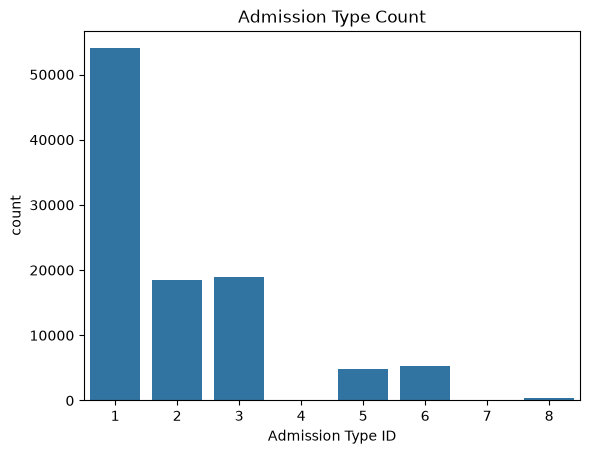

In [9]:
admission_type_col = X['admission_type_id'].value_counts()

sns.barplot(data=admission_type_col)
plt.title('Admission Type Count')
plt.xlabel('Admission Type ID')

Admission Type ID:
- 1 = Emergency
- 2 = Urgent
- 3 = Elective
- 4 = Newborn
- 5 = N/A
- 6 = NULL
- 7 = Trauma Center
- 8 =Not Mapped

Text(0.5, 0, 'Admission Source ID')

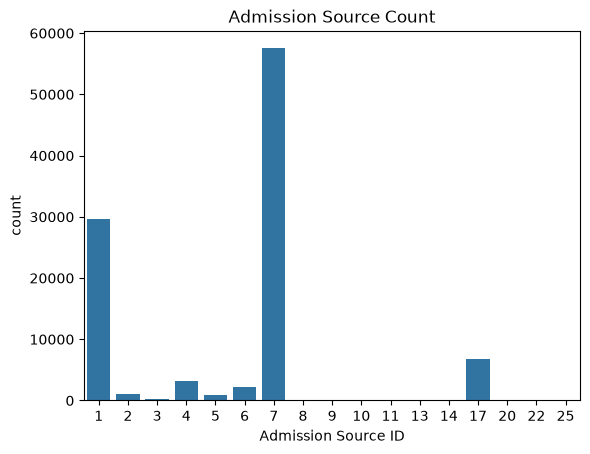

In [10]:
admission_source_col = X['admission_source_id'].value_counts()

sns.barplot(data=admission_source_col)
plt.title('Admission Source Count')
plt.xlabel('Admission Source ID')

Most Prominent Admission Source ID:
- 1 = Physician Referral
- 7 = Emergency Room
- 17 = Null 

Text(0.5, 1.0, 'Proportion of Patients on Diabetes Medication')

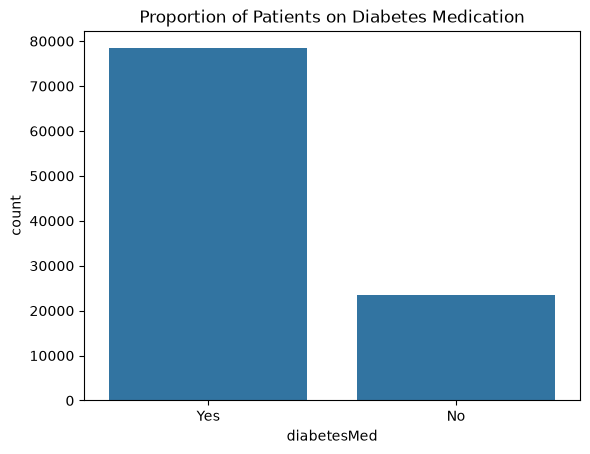

In [11]:
count_onMed = X['diabetesMed'].value_counts(ascending=False)

sns.barplot(data=count_onMed)
plt.title('Proportion of Patients on Diabetes Medication')

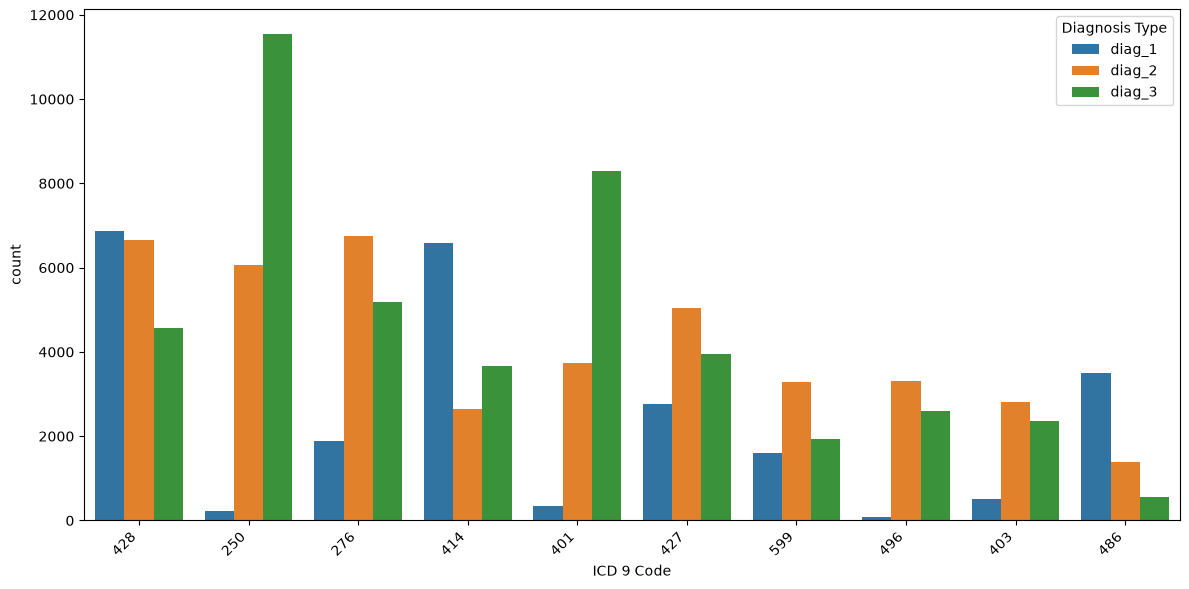

In [12]:
diag_long = pd.melt(
    X[['diag_1', 'diag_2', 'diag_3']],
    var_name='Diagnosis Type',
    value_name='ICD 9 Code'
)

plt.figure(figsize=(12, 6))
top_codes = diag_long['ICD 9 Code'].value_counts().head(10).index
sns.countplot(data=diag_long[diag_long['ICD 9 Code'].isin(top_codes)],
              x='ICD 9 Code', hue='Diagnosis Type',
              order=top_codes)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
X[['num_lab_procedures', 'num_procedures', 'num_medications']].describe()

,num_lab_procedures,num_procedures,num_medications
count,101766.000000,101766.000000,101766.000000
mean,43.095641,1.339730,16.021844
std,19.674362,1.705807,8.127566
min,1.000000,0.000000,1.000000
25%,31.000000,0.000000,10.000000
50%,44.000000,1.000000,15.000000
75%,57.000000,2.000000,20.000000
max,132.000000,6.000000,81.000000


In [14]:
# Percentage of missing values per feature
missing_pct = (X.isnull().sum() / len(X)) * 100

# Filter and display only features with missing values
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(missing_pct.to_string())

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


In [15]:
X['gender'] = (X['gender'] == 'Male').astype(int)

age_mapping = {
    '[0-10)': 1,
    '[10-20)': 2,
    '[20-30)': 3,
    '[30-40)': 4,
    '[40-50)': 5,
    '[50-60)': 6,
    '[60-70)': 7,
    '[70-80)': 8,
    '[80-90)': 9,
    '[90-100)': 10
}

X['age'] = X['age'].map(age_mapping)

In [16]:
#remove weight, max_glu_serum, A1Cresult, medical_specialty and payer code 
#because of the large amount of missing values
copyX_df = X.drop(columns=['weight', 'medical_specialty', 'payer_code'])
copyX_df.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,0,1,6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,0,2,1,1,7,3,59,0,18,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,0,3,1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,1,4,1,1,7,2,44,1,16,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,1,5,1,1,7,1,51,0,8,...,No,No,Steady,No,No,No,No,No,Ch,Yes
5,Caucasian,1,6,2,1,2,3,31,6,16,...,No,No,Steady,No,No,No,No,No,No,Yes
6,Caucasian,1,7,3,1,2,4,70,1,21,...,No,No,Steady,No,No,No,No,No,Ch,Yes
7,Caucasian,1,8,1,1,7,5,73,0,12,...,No,No,No,No,No,No,No,No,No,Yes
8,Caucasian,0,9,2,1,4,13,68,2,28,...,No,No,Steady,No,No,No,No,No,Ch,Yes
9,Caucasian,0,10,3,3,4,12,33,3,18,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [17]:
copyX_df.shape

(101766, 44)

In [18]:
comp_data = pd.concat([copyX_df, y], axis=1)

comp_data.dropna(inplace=True)
comp_data.head(10)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
162,Caucasian,1,9,6,3,7,5,47,1,6,...,No,No,No,No,No,No,No,No,No,1
460,AfricanAmerican,0,8,6,1,7,10,72,1,19,...,No,Up,No,No,No,No,No,Ch,Yes,0
593,Caucasian,0,6,6,1,7,2,61,0,5,...,No,Steady,No,No,No,No,No,No,Yes,0
696,Other,1,8,6,6,7,11,71,1,20,...,No,No,No,No,No,No,No,No,Yes,0
771,Caucasian,0,4,6,1,2,14,43,0,11,...,No,No,No,No,No,No,No,No,No,0
823,Caucasian,1,9,6,1,7,7,105,3,16,...,No,No,No,No,No,No,No,No,Yes,0
961,Hispanic,0,6,6,1,7,2,66,0,3,...,No,No,No,No,No,No,No,No,Yes,1
1280,Caucasian,0,5,6,1,7,3,76,0,9,...,No,No,No,No,No,No,No,Ch,Yes,0
1755,Caucasian,0,6,6,1,7,2,43,0,13,...,No,No,No,No,No,No,No,No,No,0
1983,Caucasian,1,6,6,10,1,4,41,1,8,...,No,No,No,No,No,No,No,No,Yes,0


In [19]:
comp_data.isna().any(axis=None)


np.False_

In [20]:
comp_data.columns

Index(['race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

# Research Questions

1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

2. Are there factors that are strongly correlated to a patient being readmitted? In the same context, are there factors that are correlated with patients not being readmitted?

3. Despite the significant amount of data missing for payer_code for patients, how does the type of insurance affect a patient's readmission state? Are they less likely to be readmitted if there insurance is private?

# Data Processing for ML

In [25]:
ml_data = comp_data.copy()

med_mapping = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}

med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

for col in med_cols:
    if col in ml_data.columns:
        ml_data[col] = ml_data[col].map(med_mapping)

ml_data = pd.get_dummies(ml_data, columns=['change','diabetesMed', 'max_glu_serum','A1Cresult'], dtype=int , drop_first=True)

ml_data = ml_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id','race'])
ml_data.head(10)

,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,readmitted,change_No,diabetesMed_Yes,max_glu_serum_>300,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_Norm
162,1,9,5,47,1,6,0,0,0,5,...,0,0,0,1,1,0,0,0,0,1
460,0,8,10,72,1,19,0,0,0,5,...,0,0,0,0,0,1,1,0,1,0
593,0,6,2,61,0,5,0,0,0,5,...,0,0,0,0,1,1,1,0,1,0
696,1,8,11,71,1,20,0,0,0,5,...,0,0,0,0,1,1,0,0,0,0
771,0,4,14,43,0,11,0,0,0,3,...,0,0,0,0,1,0,0,1,0,0
823,1,9,7,105,3,16,0,0,0,5,...,0,0,0,0,1,1,1,0,0,0
961,0,6,2,66,0,3,0,0,0,3,...,0,0,0,1,1,1,0,1,0,0
1280,0,5,3,76,0,9,0,0,0,5,...,0,0,0,0,0,1,1,0,0,0
1755,0,6,2,43,0,13,0,0,0,5,...,0,0,0,0,1,0,1,0,0,0
1983,1,6,4,41,1,8,0,0,0,3,...,0,0,0,0,1,1,0,0,1,0


In [26]:
ml_data.columns

Index(['gender', 'age', 'time_in_hospital', 'num_lab_procedures',
       'num_procedures', 'num_medications', 'number_outpatient',
       'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'readmitted', 'change_No', 'diabetesMed_Yes',
       'max_glu_serum_>300', 'max_glu_serum_Norm', 'A1Cresult_>8',
       'A1Cresult_Norm'],
      dtype='str')

In [27]:
#Isolate target variable
train_feat = ml_data.drop(columns=['readmitted'])
target = ml_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val, X_test, y_train_val, y_test = train_test_split(train_feat, target, test_size=0.2, random_state=42, stratify=target)

#Now split remaining dataset into validation and training set
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

In [39]:
print(f"Number of rows in training set: {len(X_train), len(y_train)}")
print(f"Number of rows in validation set: {len(X_val), len(y_val)}")
print(f"Number of rows in test set: {len(X_test), len(y_test)}")

Number of rows in training set: (58831, 58831)
Number of rows in validation set: (19611, 19611)
Number of rows in test set: (19611, 19611)


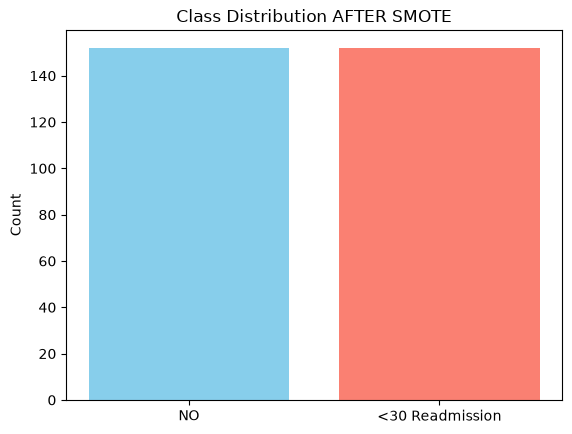

In [39]:
cat_cols = ['gender', 'age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide','tolbutamide', 
            'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
            'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 
            'metformin-pioglitazone', 'change_No', 'diabetesMed_Yes', 'max_glu_serum_>300', 
            'max_glu_serum_Norm', 'A1Cresult_>8', 'A1Cresult_Norm']

categorical_features = [X_train.columns.get_loc(c) for c in cat_cols]

smote = SMOTENC(sampling_strategy='minority', random_state=42, categorical_features=categorical_features)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=['skyblue','salmon'])
plt.xticks([0,1], ['NO', '<30 Readmission'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

# 1. What machine learning classifier algorithm is best for predicting the readmission state (>30, <30, NO) for each diabetes patient?

The main goal of this research question is to try and build a meaningful model to predict the readmission state of a diabetic patient from the dataset. 

The plan is to start off with very generic prebuilt models, such as scikit-learn logistic regression, Decision Trees, etc., and end with building my own model. I expect to have to build a my own model because the generic models will not be tuned enough to accurately predict the dataset.

### Logistic Regression

In [40]:
readmitted_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
readmitted_pred_LogR.fit(X_train, y_train)

pred_train_LogR = readmitted_pred_LogR.predict(X_train)
pred_val_LogR = readmitted_pred_LogR.predict(X_val)
pred_test_logR = readmitted_pred_LogR.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR)}")
print(f"Testing accuracy: {accuracy_score(y_val, pred_val_LogR)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_logR)}")

Training accuracy: 0.6878612716763006
Testing accuracy: 0.6379310344827587
Testing accuracy: 0.6551724137931034


Confusion matrix, without normalization
[[34 17]
 [ 3  4]]
Normalized confusion matrix
[[0.66666667 0.33333333]
 [0.42857143 0.57142857]]


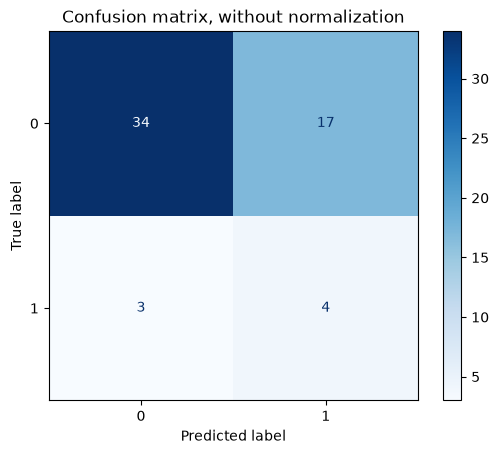

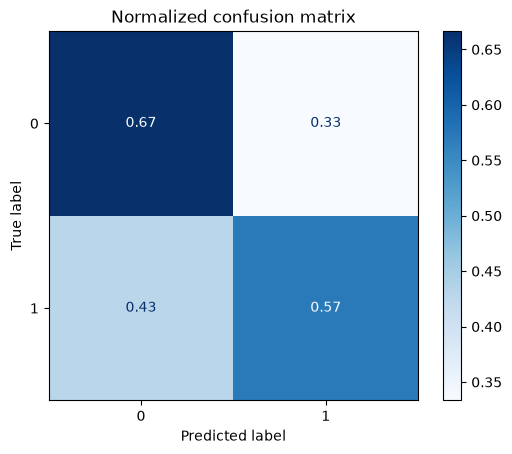

In [41]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [42]:
readmitted_pred_LogR_SMOTE = LogisticRegression(max_iter = 5000, random_state= 42)
readmitted_pred_LogR_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_LogR_SMOTE = readmitted_pred_LogR_SMOTE.predict(X_train)
pred_test_logR_SMOTE = readmitted_pred_LogR_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_LogR_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_logR_SMOTE)}")

Training accuracy: 0.7687861271676301
Testing accuracy: 0.7241379310344828


Confusion matrix, without normalization
[[41 10]
 [ 6  1]]
Normalized confusion matrix
[[0.80392157 0.19607843]
 [0.85714286 0.14285714]]


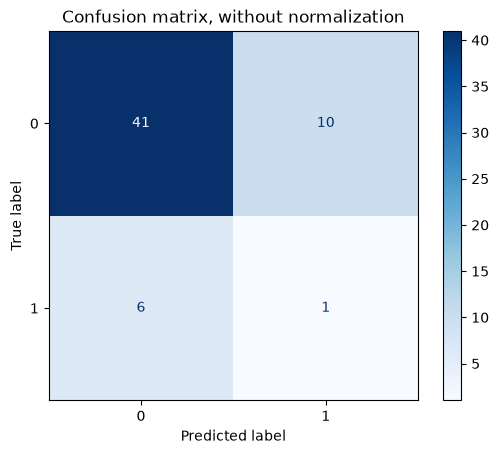

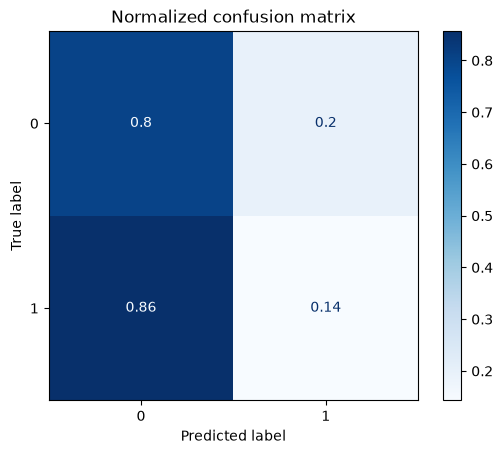

In [43]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_LogR_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

### Decision Tree Classifier

In [45]:
readmitted_pred_DT = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT.fit(X_train, y_train)

pred_train_DT = readmitted_pred_DT.predict(X_train)
pred_val_DT = readmitted_pred_DT.predict(X_val)
pred_test_DT = readmitted_pred_DT.predict(X_test)

print(f"Decision Tree Training accuracy: {accuracy_score(y_train, pred_train_DT)}")
print(f"Decision Tree Validation accuracy: {accuracy_score(y_val, pred_val_DT)}")
print(f"Decistion Tree Testing accuracy: {accuracy_score(y_test, pred_test_DT)}")

Decision Tree Training accuracy: 1.0
Decision Tree Validation accuracy: 0.7758620689655172
Decistion Tree Testing accuracy: 0.7586206896551724


Confusion matrix, without normalization
[[44  7]
 [ 7  0]]
Normalized confusion matrix
[[0.8627451 0.1372549]
 [1.        0.       ]]


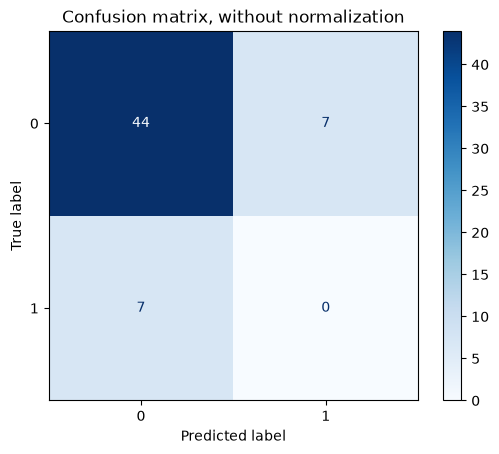

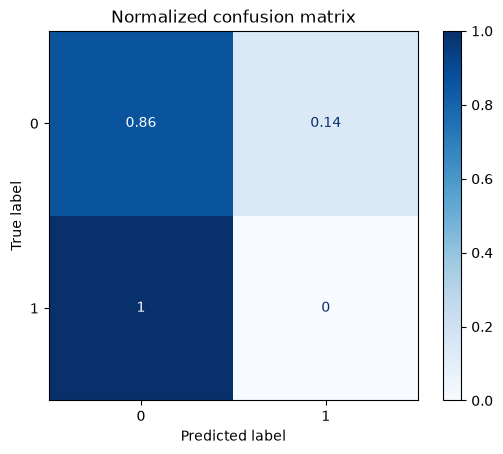

In [34]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_DT,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [35]:
readmitted_pred_DT_SMOTE = DecisionTreeClassifier(max_leaf_nodes=len(X.columns), random_state= 42)
readmitted_pred_DT_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_DT_SMOTE = readmitted_pred_DT_SMOTE.predict(X_train)
pred_test_DT_SMOTE = readmitted_pred_DT_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_DT_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_DT_SMOTE)}")

Training accuracy: 1.0
Testing accuracy: 0.7586206896551724


Confusion matrix, without normalization
[[42  9]
 [ 5  2]]
Normalized confusion matrix
[[0.82352941 0.17647059]
 [0.71428571 0.28571429]]


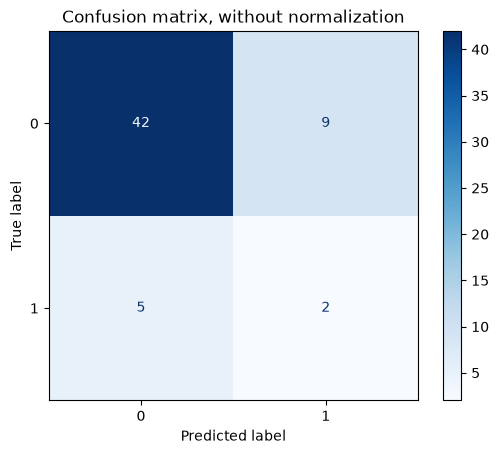

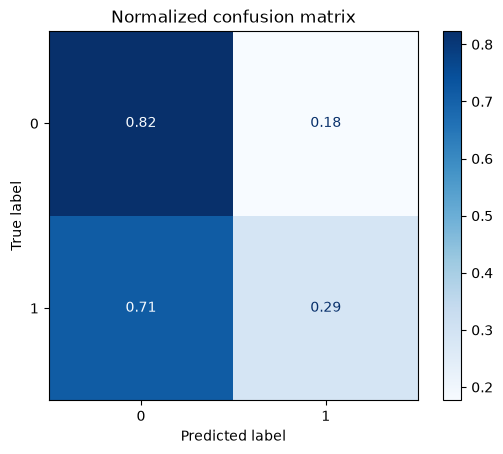

In [36]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_DT_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

### SVM Classifier 

In [37]:
readmitted_pred_SVM = svm.SVC(kernel='rbf', C=2, random_state=42)
readmitted_pred_SVM.fit(X_train, y_train)

pred_train_SVM = readmitted_pred_SVM.predict(X_train)
pred_val_SVM = readmitted_pred_SVM.predict(X_val)
pred_test_SVM = readmitted_pred_SVM.predict(X_test)


print(f"SVM RBF CLF Training accuracy: {accuracy_score(y_train, pred_train_SVM)}")
print(f"SVM RBF CLF Validation accuracy: {accuracy_score(y_val, pred_val_SVM)}")
print(f"SVM RBF CLF Testing accuracy: {accuracy_score(y_test, pred_test_SVM)}")

SVM RBF CLF Training accuracy: 0.8786127167630058
SVM RBF CLF Validation accuracy: 0.8793103448275862
SVM RBF CLF Testing accuracy: 0.8793103448275862


Confusion matrix, without normalization
[[51  0]
 [ 7  0]]
Normalized confusion matrix
[[1. 0.]
 [1. 0.]]


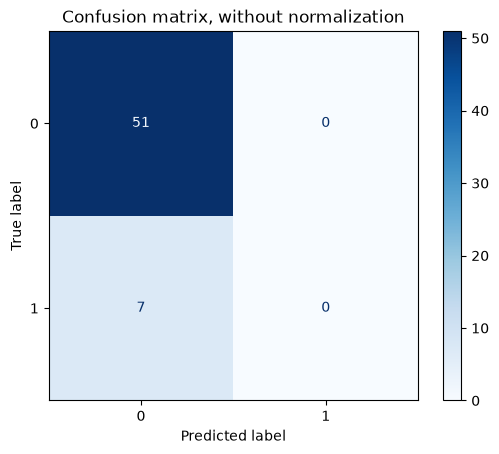

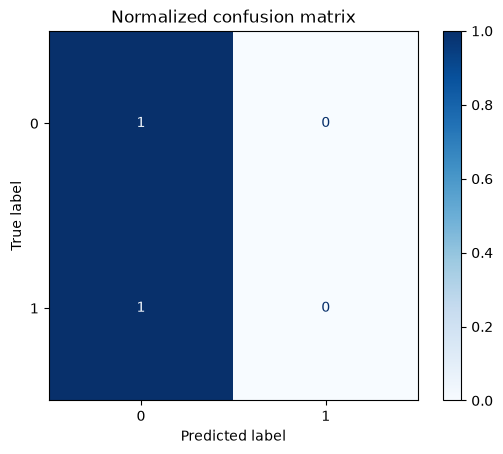

In [38]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_SVM,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_SVM_SMOTE = svm.SVC(kernel='rbf', C=2, random_state=42)
readmitted_pred_SVM_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_train)
pred_test_SVM_SMOTE = readmitted_pred_SVM_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_SVM_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_SVM_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_SVM_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

### Random Forest Classifier

In [ ]:
readmitted_pred_RF = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
readmitted_pred_RF.fit(X_train, y_train)

pred_train_RF = readmitted_pred_RF.predict(X_train)
pred_val_RF = readmitted_pred_RF.predict(X_val)
pred_test_RF = readmitted_pred_RF.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_RF)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_RF)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_RF,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

In [ ]:
readmitted_pred_RF_SMOTE = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
readmitted_pred_RF_SMOTE.fit(X_train_sm, y_train_sm)

pred_train_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_train)
pred_val_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_val)
pred_test_RF_SMOTE = readmitted_pred_RF_SMOTE.predict(X_test)

print(f"Training accuracy: {accuracy_score(y_train, pred_train_RF_SMOTE)}")
print(f"Validation accuracy: {accuracy_score(y_val, pred_val_RF_SMOTE)}")
print(f"Testing accuracy: {accuracy_score(y_test, pred_test_RF_SMOTE)}")

In [ ]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        readmitted_pred_RF_SMOTE,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Model Comparison

In [ ]:
#Logistic Regression Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_logR)
print(f"LogR Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_logR))

accuracy = accuracy_score(y_test, pred_test_logR_SMOTE)
print(f"LogR Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_logR_SMOTE))


In [ ]:
#Decisiion Tree Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_DT)
print(f"DT Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_DT))

accuracy = accuracy_score(y_test, pred_test_DT_SMOTE)
print(f"DT Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_DT_SMOTE))

In [ ]:
#SVM Classifier Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_SVM)
print(f"SVM Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_SVM))

accuracy = accuracy_score(y_test, pred_test_SVM_SMOTE)
print(f"SVM Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_SVM_SMOTE))

In [ ]:
#Random Forest Performance w/ and w/o SMOTE
accuracy = accuracy_score(y_test, pred_test_RF)
print(f"RF Model Accuracy w/o SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_RF_SMOTE))

accuracy = accuracy_score(y_test, pred_test_RF_SMOTE)
print(f"RF Model Accuracy w/ SMOTE: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, pred_test_RF_SMOTE))

### Area Under the Receiver Operating Characteristic curve (AUROC)

In [ ]:
#AUROC graphs
fig, ax = plt.subplots(1,2, figsize = (15,5))
RocCurveDisplay.from_estimator(readmitted_pred_LogR, X_test, y_test, ax=ax[0], name="LogReg")
RocCurveDisplay.from_estimator(readmitted_pred_DT, X_test, y_test, ax=ax[0], name="DT")
RocCurveDisplay.from_estimator(readmitted_pred_SVM, X_test, y_test, ax=ax[0], name="SVM")
RocCurveDisplay.from_estimator(readmitted_pred_RF, X_test, y_test, ax=ax[0], name="RF")

RocCurveDisplay.from_estimator(readmitted_pred_LogR_SMOTE, X_test, y_test, ax=ax[1], name="LogRegSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_DT_SMOTE, X_test, y_test, ax=ax[1], name="DTSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_SVM_SMOTE, X_test, y_test, ax=ax[1], name="SVMSMOTE")
RocCurveDisplay.from_estimator(readmitted_pred_RF_SMOTE, X_test, y_test, ax=ax[1], name="RFSMOTE")

plt.show()

### Area Under the Precision-Recall Curve (AUPRC)

In [ ]:
#AUPRC Graphs
model_groups = {
    "Logistic Regression": {
        "Original": readmitted_pred_LogR,
        "SMOTE": readmitted_pred_LogR_SMOTE,
    },
    "Decision Tree": {
        "Original": readmitted_pred_DT,
        "SMOTE": readmitted_pred_DT_SMOTE,
    },
    "Random Forest": {
        "Original": readmitted_pred_RF,
        "SMOTE": readmitted_pred_RF_SMOTE,
    },
}

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
axes = axes.ravel()  # flatten 2x2 grid into a list of 4 for easy indexing

for ax, (algo_name, variants) in zip(axes, model_groups.items()):
    for label, model in variants.items():
        y_prob = model.predict_proba(X_val)[:, 1]  # always score on validation, both variants
        precision, recall, _ = precision_recall_curve(y_val, y_prob)
        ap = average_precision_score(y_val, y_prob)
        ax.plot(recall, precision, label=f"{label} (AP={ap:.3f})")

    ax.set_title(algo_name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Stratified Analysis Across Race
Stratified analysis for comparing model performance on differenct races.

In [ ]:
race_data = comp_data.copy()

#apply map to medication columns
for col in med_cols:
    if col in race_data.columns:
        race_data[col] = race_data[col].map(med_mapping)

#convert yes/no columns to integers
race_data = pd.get_dummies(race_data, columns=['change','diabetesMed'], dtype=int , drop_first=True)

race_data = race_data.drop(columns=['diag_1', 'diag_2', 'diag_3', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id',])

asian_data = race_data[race_data['race'] == 'Asian']


In [30]:
#split data
asian_train_feat = asian_data.drop(columns=['readmitted', 'race'])
asian_target = asian_data['readmitted']

#Split dataset so 20% is test, 80% is the remaining data
X_train_val_asian, X_test_asian, y_train_val_asian, y_test_asian = train_test_split(asian_train_feat, asian_target, test_size=0.2, random_state=42, stratify=asian_target)

#Now split remaining dataset into validation and training set
X_train_asian, X_val_asian, y_train_asian, y_val_asian = train_test_split(X_train_val_asian, y_train_val_asian, test_size=0.25, random_state=42, stratify=y_train_val_asian)

In [31]:
asian_pred_LogR = LogisticRegression(max_iter = 1000, random_state= 42, class_weight='balanced')
asian_pred_LogR.fit(X_train_asian, y_train_asian)

asian_pred_train_LogR = asian_pred_LogR.predict(X_train_asian)
asian_pred_val_LogR = asian_pred_LogR.predict(X_val_asian)
asian_pred_test_logR = asian_pred_LogR.predict(X_test_asian)

print(f"Training accuracy on Asian set: {accuracy_score(y_train_asian, asian_pred_train_LogR)}")
print(f"Validation accuracy on Asian set: {accuracy_score(y_val_asian, asian_pred_val_LogR)}")
print(f"Testing accuracy on Asian set: {accuracy_score(y_test_asian, asian_pred_test_logR)}")

Training accuracy on Asian set: 0.728
Validation accuracy on Asian set: 0.624
Testing accuracy on Asian set: 0.68


Confusion matrix, without normalization
[[11220  6178]
 [ 1170  1043]]
Normalized confusion matrix
[[0.64490171 0.35509829]
 [0.52869408 0.47130592]]


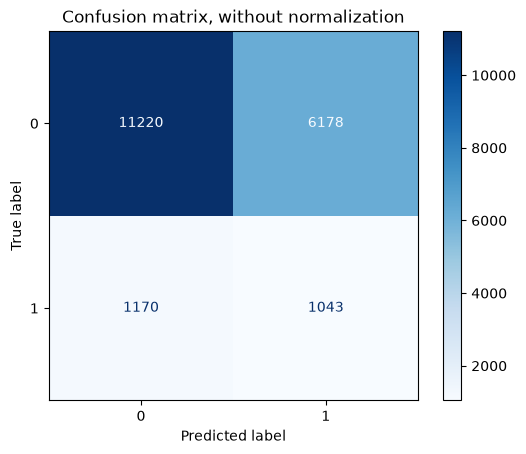

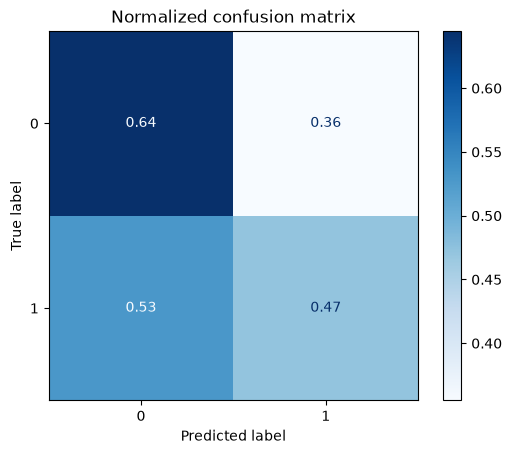

In [32]:
class_names = [0, 1]

titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        asian_pred_LogR,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#Sensitivity = TP / (TP + FN) = 0.90, Specificity = TN / (TN + FP) = 0.14
#PPV = TP / (TP + FP) = 0.77, NPV = TN / (TN + FP) = 0.29

# 2. Are there factors that are strongly correlated to a patient being readmitted? In the same context, are there factors that are correlated with patients not being readmitted?

Perform correlation analysis with diagnosis using ICD 9 codes.

In [ ]:
diag_data = comp_data[['diag_1','diag_2','diag_3']]
diag_data.head(10)

In [ ]:
CHAPTER_RANGES = [
    (1, 139, "Infectious/parasitic"),
    (140, 239, "Neoplasms"),
    (240, 249, "Endocrine/metabolic/immunity (non-diabetes)"),
    (251, 279, "Endocrine/metabolic/immunity (non-diabetes)"),
    (280, 289, "Blood"),
    (290, 319, "Mental disorders"),
    (320, 389, "Nervous system/sense organs"),
    (390, 459, "Circulatory"),
    (460, 519, "Respiratory"),
    (520, 579, "Digestive"),
    (580, 629, "Genitourinary"),
    (630, 679, "Pregnancy/childbirth"),
    (680, 709, "Skin"),
    (710, 739, "Musculoskeletal"),
    (740, 759, "Congenital anomalies"),
    (760, 779, "Perinatal"),
    (780, 799, "Symptoms/ill-defined"),
    (800, 999, "Injury/poisoning"),
]


def map_code_to_chapter(raw_code):
    """Map a single raw ICD-9 code (string) to a chapter label.
    Handles: missing ('?'/NaN), diabetes split-out, V-codes, E-codes,
    and numeric-with-decimal codes (e.g. '250.01', '414.01')."""
    if pd.isna(raw_code):
        return "Missing"
    code = str(raw_code).strip()
    if code == "?" or code == "":
        return "Missing"

    # V-codes and E-codes are alphanumeric, not in the numeric ranges.
    if code.upper().startswith("V"):
        return "Supplemental (V-code)"
    if code.upper().startswith("E"):
        return "External causes (E-code)"

    # Diabetes pulled out specifically (250.xx, any subcode).
    try:
        numeric_val = float(code)
    except ValueError:
        return "Unrecognized/Other"

    if 250 <= numeric_val < 251:
        return "Diabetes (250.xx)"

    for low, high, label in CHAPTER_RANGES:
        if low <= numeric_val <= high:
            return label

    return "Unrecognized/Other"

group_Diag = pd.DataFrame()
chapter_cols = []
for c in diag_data:
    new_col = f"{c}_chapter"
    group_Diag[new_col] = diag_data[c].apply(map_code_to_chapter)
    chapter_cols.append(new_col)

group_Diag.head(10)


In [ ]:
correl_data = pd.concat([group_Diag, comp_data['readmitted']], axis=1)
correl_data.head(10)

In [ ]:
correl_data.shape

Correlation analysis of Hospital readmission using just numerical values.

In [ ]:
#correlation analysis of hospital readmission
comp_data.columns